# SHA Layer-Stack Deconvolution

## Carry-Plane-Assisted XOR Peeling

This notebook codes the exact rail:

$$
\boxed{\text{SHA is a rotation/XOR matrix stack whose peel is blocked by hidden carry layers.}}
$$

It does **not** claim generic SHA-256 inversion. It demonstrates the executable structure:

1. Pure XOR / rotation layers are exactly peelable.
2. Modular addition is XOR plus a carry/scar plane.
3. If the carry/scar plane is known, modular addition becomes peelable.
4. The SHA-256 message schedule can be rewritten exactly as an XOR layer plus a carry scar.
5. Unknown carry/scar planes are the hidden sheets that block direct peeling.

Core identity:

$$
W_t
=
\sigma_1(W_{t-2})
+
W_{t-7}
+
\sigma_0(W_{t-15})
+
W_{t-16}
\pmod{2^{32}}
$$

becomes:

$$
\boxed{
W_t
=
\sigma_1(W_{t-2})
\oplus
W_{t-7}
\oplus
\sigma_0(W_{t-15})
\oplus
W_{t-16}
\oplus
S_t
}
$$

where:

$$
\boxed{
S_t
=
W_t
\oplus
\left(
\sigma_1(W_{t-2})
\oplus
W_{t-7}
\oplus
\sigma_0(W_{t-15})
\oplus
W_{t-16}
\right)
}
$$

is the carry scar plane.


In [1]:
# Top cell: imports and global settings

import hashlib
import random
import math
from collections import Counter, defaultdict
from typing import List, Tuple

import numpy as np
import matplotlib.pyplot as plt

MASK = 0xFFFFFFFF
WORD_BITS = 32
SEED = 20260430
random.seed(SEED)
np.random.seed(SEED)

print("Notebook initialized")
print(f"MASK = {MASK:#010x}")


Notebook initialized
MASK = 0xffffffff


In [2]:
# SHA-256 primitive utilities

def u32(x: int) -> int:
    return x & MASK

def rotr(x: int, n: int) -> int:
    return ((x >> n) | ((x << (32 - n)) & MASK)) & MASK

def shr(x: int, n: int) -> int:
    return (x >> n) & MASK

def Sigma0(x: int) -> int:
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def Sigma1(x: int) -> int:
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def sigma0(x: int) -> int:
    return rotr(x, 7) ^ rotr(x, 18) ^ shr(x, 3)

def sigma1(x: int) -> int:
    return rotr(x, 17) ^ rotr(x, 19) ^ shr(x, 10)

def ch(x: int, y: int, z: int) -> int:
    return (x & y) ^ ((~x) & z)

def maj(x: int, y: int, z: int) -> int:
    return (x & y) ^ (x & z) ^ (y & z)

def hw(x: int) -> int:
    return int(x & MASK).bit_count()

def word_to_bits(x: int) -> List[int]:
    return [(x >> i) & 1 for i in range(32)]

def bits_to_word(bits: List[int]) -> int:
    out = 0
    for i, b in enumerate(bits[:32]):
        out |= (int(b) & 1) << i
    return out & MASK

def fmtw(x: int) -> str:
    return f"{x & MASK:08x}"

print("SHA utility functions loaded")


SHA utility functions loaded


## Stage 1 — Pure XOR / rotation stack

If the layers are XOR and invertible permutations, the stack peels exactly.


In [3]:
def xor_layer_forward(x: int, key: int, rot: int) -> int:
    """
    y = ROTR(x, rot) XOR key
    """
    return rotr(x, rot) ^ key

def xor_layer_inverse(y: int, key: int, rot: int) -> int:
    """
    y = ROTR(x, rot) XOR key
    x = ROTL(y XOR key, rot)
    ROTL by rot = ROTR by 32-rot.
    """
    return rotr(y ^ key, 32 - rot)

def run_xor_stack(x0: int, layers: List[Tuple[int, int]]) -> List[int]:
    states = [x0]
    x = x0
    for key, rot in layers:
        x = xor_layer_forward(x, key, rot)
        states.append(x)
    return states

def peel_xor_stack(top: int, layers: List[Tuple[int, int]]) -> List[int]:
    states = [top]
    x = top
    for key, rot in reversed(layers):
        x = xor_layer_inverse(x, key, rot)
        states.append(x)
    return states

layers = [(random.getrandbits(32), random.randrange(1, 32)) for _ in range(12)]
x0 = random.getrandbits(32)
states = run_xor_stack(x0, layers)
peeled = peel_xor_stack(states[-1], layers)

print("Pure XOR/rotation stack")
print(f"initial: {fmtw(x0)}")
print(f"top:     {fmtw(states[-1])}")
print(f"peeled:  {fmtw(peeled[-1])}")
print("Exact peel:", peeled[-1] == x0)


Pure XOR/rotation stack
initial: f9fcdf06
top:     56f71c10
peeled:  f9fcdf06
Exact peel: True


## Stage 2 — Addition as XOR plus carry scar

Modular addition is not just value addition. It creates hidden carry planes.

For operands $x_1,\dots,x_k$:

$$
S = \left(\sum_i x_i \bmod 2^{32}\right) \oplus \left(\bigoplus_i x_i\right)
$$

The scar $S$ is the hidden sheet that makes the XOR face equal the modular-add result.


In [4]:
def add_mod(*xs: int) -> int:
    return sum(xs) & MASK

def xor_sum(*xs: int) -> int:
    out = 0
    for x in xs:
        out ^= x & MASK
    return out & MASK

def carry_scar_for_add(*xs: int) -> int:
    """
    Scar plane for k-operand modular addition:
        S = (sum mod 2^32) XOR (xor of operands)
    """
    return add_mod(*xs) ^ xor_sum(*xs)

def carry_counts_for_add(*xs: int) -> List[int]:
    """
    Integer carry count entering each bit column.
    q[0] = 0.
    q[j+1] = floor((q[j] + sum_i bit_j(x_i))/2).
    """
    q = [0]
    carry = 0
    for j in range(32):
        column_sum = carry + sum((x >> j) & 1 for x in xs)
        carry = column_sum // 2
        q.append(carry)
    return q

def scar_from_carry_counts(q: List[int]) -> int:
    """
    Scar bit at j is q[j] mod 2.
    """
    bits = [(q[j] & 1) for j in range(32)]
    return bits_to_word(bits)

a, b, c, d = [random.getrandbits(32) for _ in range(4)]
s_add = add_mod(a, b, c, d)
s_xor = xor_sum(a, b, c, d)
scar = carry_scar_for_add(a, b, c, d)
q = carry_counts_for_add(a, b, c, d)
scar_q = scar_from_carry_counts(q)

print("ADD = XOR face + carry scar")
print("operands:", [fmtw(x) for x in (a,b,c,d)])
print("ADD:     ", fmtw(s_add))
print("XOR:     ", fmtw(s_xor))
print("scar:    ", fmtw(scar))
print("XOR^scar:", fmtw(s_xor ^ scar))
print("scar from carry parity:", fmtw(scar_q))
print("Identity holds:", s_add == (s_xor ^ scar) == (s_xor ^ scar_q))
print("Universal LSB scar = 0:", (scar & 1) == 0)


ADD = XOR face + carry scar
operands: ['059bc428', '0fe244cb', '75b1d766', 'a86e25b9']
ADD:      339e0612
XOR:      d7a6723c
scar:     e438742e
XOR^scar: 339e0612
scar from carry parity: e438742e
Identity holds: True
Universal LSB scar = 0: True


In [5]:
# If the carry scar is known, an ADD layer becomes peelable.

def recover_missing_operand_from_known_scar(total: int, known_operands: List[int], scar: int) -> int:
    """
    Given:
        total = x XOR known_1 XOR ... XOR known_n XOR scar
    Recover:
        x = total XOR known_1 XOR ... XOR known_n XOR scar
    """
    x = total ^ scar
    for k in known_operands:
        x ^= k
    return x & MASK

x = random.getrandbits(32)
known = [random.getrandbits(32) for _ in range(3)]
total = add_mod(x, *known)
scar = carry_scar_for_add(x, *known)
x_rec = recover_missing_operand_from_known_scar(total, known, scar)

print("Carry-plane-assisted ADD peel")
print("x true:", fmtw(x))
print("x rec: ", fmtw(x_rec))
print("Exact:", x == x_rec)


Carry-plane-assisted ADD peel
x true: 8ef4fb5c
x rec:  8ef4fb5c
Exact: True


## Stage 3 — SHA-256 schedule as XOR face plus carry scar

This is the exact schedule-layer identity.


In [6]:
def message_to_block_words(msg: bytes) -> List[int]:
    """
    Single-block SHA-256 padding. Valid for len(msg) <= 55.
    Returns W[0..15].
    """
    if len(msg) > 55:
        raise ValueError("This notebook cell handles one-block messages only: len(msg) <= 55.")
    ml = len(msg) * 8
    block = bytearray(msg)
    block.append(0x80)
    while len(block) != 56:
        block.append(0)
    block += ml.to_bytes(8, "big")
    assert len(block) == 64
    return [int.from_bytes(block[i:i+4], "big") for i in range(0, 64, 4)]

def expand_schedule(words16: List[int]) -> List[int]:
    W = list(words16) + [0] * 48
    for t in range(16, 64):
        W[t] = add_mod(sigma1(W[t-2]), W[t-7], sigma0(W[t-15]), W[t-16])
    return W

def expand_schedule_with_scars(words16: List[int]) -> Tuple[List[int], List[int], List[int]]:
    """
    Returns:
        W: true schedule words
        X: XOR-face words for t>=16 stored at index t, zero for <16
        S: carry-scar words for t>=16 stored at index t, zero for <16
    """
    W = list(words16) + [0] * 48
    X = [0] * 64
    S = [0] * 64
    for t in range(16, 64):
        ops = (sigma1(W[t-2]), W[t-7], sigma0(W[t-15]), W[t-16])
        X[t] = xor_sum(*ops)
        W[t] = add_mod(*ops)
        S[t] = W[t] ^ X[t]
    return W, X, S

msg = b"Layer stack demo: XOR sheets plus carry scars."
words16 = message_to_block_words(msg)
W, Xface, Scar = expand_schedule_with_scars(words16)

print("Message:", msg)
print("First expanded words as XOR face + scar:")
for t in range(16, 24):
    print(f"W[{t:02d}]={fmtw(W[t])} | X={fmtw(Xface[t])} | S={fmtw(Scar[t])} | X^S={fmtw(Xface[t]^Scar[t])}")
print("All expanded words satisfy W = Xface XOR Scar:", all(W[t] == (Xface[t] ^ Scar[t]) for t in range(16,64)))


Message: b'Layer stack demo: XOR sheets plus carry scars.'
First expanded words as XOR face + scar:
W[16]=b9514485 | X=c46e5245 | S=7d3f16c0 | X^S=b9514485
W[17]=7c4088d0 | X=97f3a1ec | S=ebb3293c | X^S=7c4088d0
W[18]=e8ade961 | X=11ae6a9d | S=f90383fc | X^S=e8ade961
W[19]=48f6142a | X=be2bc9d4 | S=f6ddddfe | X^S=48f6142a
W[20]=4a01948b | X=b5bce075 | S=ffbd74fe | X^S=4a01948b
W[21]=d21d8187 | X=2dd89eb7 | S=ffc51f30 | X^S=d21d8187
W[22]=537f6752 | X=68f09c6c | S=3b8ffb3e | X^S=537f6752
W[23]=1ee35589 | X=3dbcacbf | S=235ff936 | X^S=1ee35589
All expanded words satisfy W = Xface XOR Scar: True


In [7]:
def reconstruct_schedule_from_seeds_and_scars(words16: List[int], scars: List[int]) -> List[int]:
    """
    Rebuild W[0..63] using only seed words W[0..15] and scar planes S[16..63].
    """
    Wrec = list(words16) + [0] * 48
    for t in range(16, 64):
        xface = xor_sum(sigma1(Wrec[t-2]), Wrec[t-7], sigma0(Wrec[t-15]), Wrec[t-16])
        Wrec[t] = xface ^ scars[t]
    return Wrec

Wrec = reconstruct_schedule_from_seeds_and_scars(words16, Scar)
print("Reconstruct schedule using seed words + scar planes")
print("Exact reconstruction:", Wrec == W)

# Local peel of one missing operand from a schedule equation.
t = 31
A = sigma1(W[t-2])
B = W[t-7]
C = sigma0(W[t-15])
D = W[t-16]
target = W[t]
scar_t = Scar[t]
D_rec = recover_missing_operand_from_known_scar(target, [A, B, C], scar_t)

print()
print(f"Local schedule peel at t={t}: recover W[t-16]")
print("true D:", fmtw(D))
print("rec  D:", fmtw(D_rec))
print("Exact:", D == D_rec)


Reconstruct schedule using seed words + scar planes
Exact reconstruction: True

Local schedule peel at t=31: recover W[t-16]
true D: 00000170
rec  D: 00000170
Exact: True


In [8]:
# If the scar plane is unknown, the XOR peel is blocked.

t = 31
A = sigma1(W[t-2])
B = W[t-7]
C = sigma0(W[t-15])
D_true = W[t-16]
target = W[t]

D_wrong = recover_missing_operand_from_known_scar(target, [A, B, C], 0)
scar_needed = target ^ xor_sum(A, B, C, D_true)

print("Unknown scar blocks the peel")
print("true D:             ", fmtw(D_true))
print("recovered w/scar=0: ", fmtw(D_wrong))
print("actual scar needed: ", fmtw(scar_needed))
print("wrong bits:", hw(D_true ^ D_wrong))


Unknown scar blocks the peel
true D:              00000170
recovered w/scar=0:  c7f97c88
actual scar needed:  c7f97df8
wrong bits: 22


## Stage 4 — Scar field visualizations


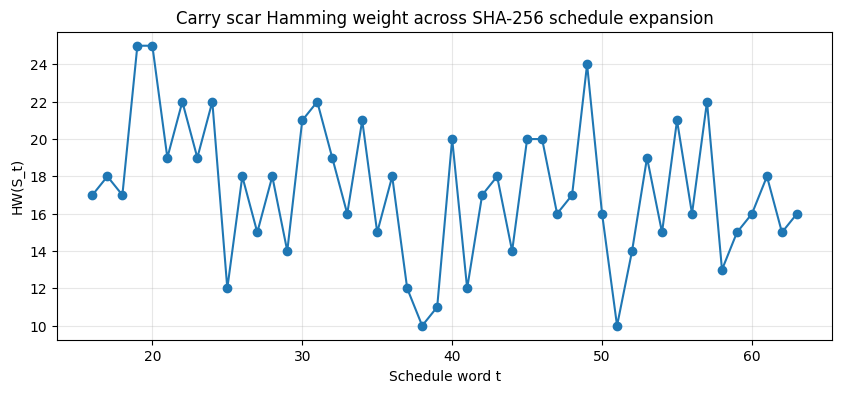

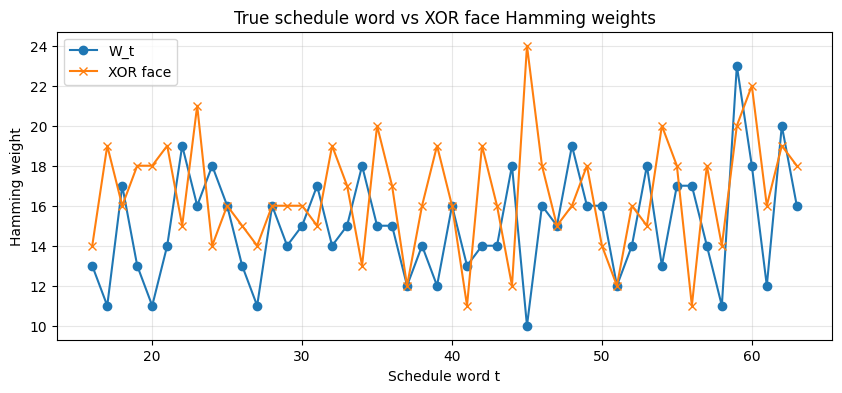

Scar HW summary
min: 10 mean: 17.292 max: 25


In [9]:
scar_hw = [hw(Scar[t]) for t in range(16, 64)]
x_hw = [hw(Xface[t]) for t in range(16, 64)]
w_hw = [hw(W[t]) for t in range(16, 64)]

plt.figure(figsize=(10, 4))
plt.plot(range(16, 64), scar_hw, marker="o")
plt.title("Carry scar Hamming weight across SHA-256 schedule expansion")
plt.xlabel("Schedule word t")
plt.ylabel("HW(S_t)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range(16, 64), w_hw, marker="o", label="W_t")
plt.plot(range(16, 64), x_hw, marker="x", label="XOR face")
plt.title("True schedule word vs XOR face Hamming weights")
plt.xlabel("Schedule word t")
plt.ylabel("Hamming weight")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Scar HW summary")
print("min:", min(scar_hw), "mean:", round(float(np.mean(scar_hw)), 3), "max:", max(scar_hw))


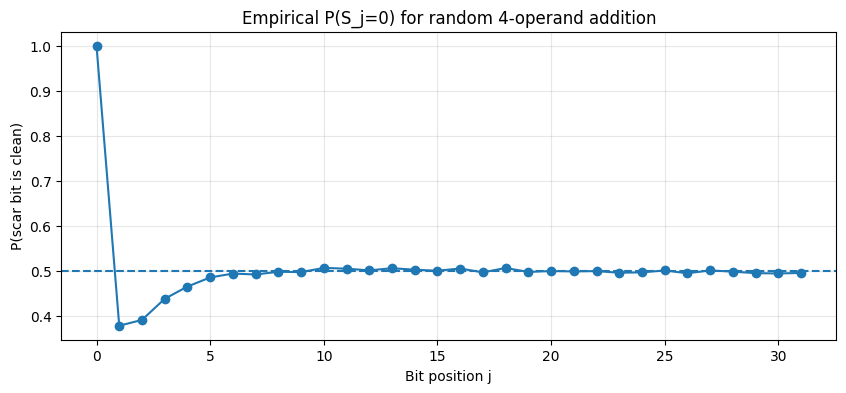

First eight clean rates for k=4:
j=0: 1.0000
j=1: 0.3786
j=2: 0.3915
j=3: 0.4384
j=4: 0.4655
j=5: 0.4858
j=6: 0.4944
j=7: 0.4924
Universal clean LSB observed: True


In [10]:
# Empirical scar bit statistics for k=4 addition.

def random_k_operand_scar(k: int, trials: int = 10000) -> np.ndarray:
    counts_clean = np.zeros(32, dtype=int)
    for _ in range(trials):
        xs = [random.getrandbits(32) for _ in range(k)]
        scar = carry_scar_for_add(*xs)
        for j in range(32):
            if ((scar >> j) & 1) == 0:
                counts_clean[j] += 1
    return counts_clean / trials

rates4 = random_k_operand_scar(4, trials=20000)

plt.figure(figsize=(10, 4))
plt.plot(range(32), rates4, marker="o")
plt.axhline(0.5, linestyle="--")
plt.title("Empirical P(S_j=0) for random 4-operand addition")
plt.xlabel("Bit position j")
plt.ylabel("P(scar bit is clean)")
plt.grid(True, alpha=0.3)
plt.show()

print("First eight clean rates for k=4:")
for j in range(8):
    print(f"j={j}: {rates4[j]:.4f}")
print("Universal clean LSB observed:", rates4[0] == 1.0)


## Stage 5 — Tiny GF(2) matrix stack

This is the pure layer-peeling version with explicit invertible binary matrices.


In [11]:
def gf2_matmul(A: np.ndarray, x: np.ndarray) -> np.ndarray:
    return (A @ x) % 2

def random_invertible_gf2_matrix(n: int) -> np.ndarray:
    A = np.eye(n, dtype=np.uint8)
    for _ in range(n * 8):
        i, j = np.random.choice(n, size=2, replace=False)
        if random.random() < 0.5:
            A[[i, j]] = A[[j, i]]
        else:
            A[i] ^= A[j]
    return A

def gf2_inverse(A: np.ndarray) -> np.ndarray:
    n = A.shape[0]
    A = A.copy().astype(np.uint8)
    I = np.eye(n, dtype=np.uint8)
    aug = np.concatenate([A, I], axis=1)
    row = 0
    for col in range(n):
        pivot = None
        for r in range(row, n):
            if aug[r, col]:
                pivot = r
                break
        if pivot is None:
            raise ValueError("Matrix not invertible")
        if pivot != row:
            aug[[row, pivot]] = aug[[pivot, row]]
        for r in range(n):
            if r != row and aug[r, col]:
                aug[r] ^= aug[row]
        row += 1
    return aug[:, n:]

n = 16
num_layers = 6
As = [random_invertible_gf2_matrix(n) for _ in range(num_layers)]
bs = [np.random.randint(0, 2, size=n, dtype=np.uint8) for _ in range(num_layers)]

x = np.random.randint(0, 2, size=n, dtype=np.uint8)
states = [x.copy()]
for A, b in zip(As, bs):
    x = gf2_matmul(A, x) ^ b
    states.append(x.copy())

top = states[-1].copy()
x_peel = top.copy()
for A, b in reversed(list(zip(As, bs))):
    invA = gf2_inverse(A)
    x_peel = gf2_matmul(invA, x_peel ^ b)

print("Tiny GF(2) matrix stack")
print("initial:", ''.join(map(str, states[0].tolist())))
print("top:    ", ''.join(map(str, top.tolist())))
print("peeled: ", ''.join(map(str, x_peel.tolist())))
print("Exact peel:", np.array_equal(x_peel, states[0]))


Tiny GF(2) matrix stack
initial: 1101101011111110
top:     1110101111110110
peeled:  1101101011111110
Exact peel: True


## Stage 6 — SHA compression trace sanity check

This verifies the notebook's one-block SHA-256 compression against `hashlib`.


In [12]:
K = [
    0x428a2f98, 0x71374491, 0xb5c0fbcf, 0xe9b5dba5,
    0x3956c25b, 0x59f111f1, 0x923f82a4, 0xab1c5ed5,
    0xd807aa98, 0x12835b01, 0x243185be, 0x550c7dc3,
    0x72be5d74, 0x80deb1fe, 0x9bdc06a7, 0xc19bf174,
    0xe49b69c1, 0xefbe4786, 0x0fc19dc6, 0x240ca1cc,
    0x2de92c6f, 0x4a7484aa, 0x5cb0a9dc, 0x76f988da,
    0x983e5152, 0xa831c66d, 0xb00327c8, 0xbf597fc7,
    0xc6e00bf3, 0xd5a79147, 0x06ca6351, 0x14292967,
    0x27b70a85, 0x2e1b2138, 0x4d2c6dfc, 0x53380d13,
    0x650a7354, 0x766a0abb, 0x81c2c92e, 0x92722c85,
    0xa2bfe8a1, 0xa81a664b, 0xc24b8b70, 0xc76c51a3,
    0xd192e819, 0xd6990624, 0xf40e3585, 0x106aa070,
    0x19a4c116, 0x1e376c08, 0x2748774c, 0x34b0bcb5,
    0x391c0cb3, 0x4ed8aa4a, 0x5b9cca4f, 0x682e6ff3,
    0x748f82ee, 0x78a5636f, 0x84c87814, 0x8cc70208,
    0x90befffa, 0xa4506ceb, 0xbef9a3f7, 0xc67178f2,
]

H0 = [
    0x6a09e667, 0xbb67ae85, 0x3c6ef372, 0xa54ff53a,
    0x510e527f, 0x9b05688c, 0x1f83d9ab, 0x5be0cd19,
]

def sha256_compress_one_block(msg: bytes):
    words16 = message_to_block_words(msg)
    W = expand_schedule(words16)
    a,b,c,d,e,f,g,h = H0
    states = [(a,b,c,d,e,f,g,h)]
    round_data = []
    for r in range(64):
        T1 = u32(h + Sigma1(e) + ch(e, f, g) + K[r] + W[r])
        T2 = u32(Sigma0(a) + maj(a, b, c))
        new_a = u32(T1 + T2)
        new_e = u32(d + T1)
        h, g, f, e, d, c, b, a = g, f, e, new_e, c, b, a, new_a
        states.append((a,b,c,d,e,f,g,h))
        round_data.append({"r": r, "W": W[r], "T1": T1, "T2": T2})
    digest_words = [u32(states[-1][i] + H0[i]) for i in range(8)]
    digest = b"".join(w.to_bytes(4, "big") for w in digest_words)
    return digest, W, states, round_data

test_msg = b"abc"
digest, Wfull, states, round_data = sha256_compress_one_block(test_msg)
print("Internal SHA implementation check")
print("our digest:     ", digest.hex())
print("hashlib digest: ", hashlib.sha256(test_msg).hexdigest())
print("Matches hashlib:", digest == hashlib.sha256(test_msg).digest())
print("Final state x64:", [fmtw(x) for x in states[-1]])


Internal SHA implementation check
our digest:      ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad
hashlib digest:  ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad
Matches hashlib: True
Final state x64: ['506e3058', 'd39a2165', '04d24d6c', 'b85e2ce9', '5ef50f24', 'fb121210', '948d25b6', '961f4894']


# Final Notes

The notebook demonstrates the exact useful rail:

$$
\boxed{\text{XOR/rotation layers are peelable.}}
$$

$$
\boxed{\text{ADD is XOR plus hidden carry/scar planes.}}
$$

$$
\boxed{\text{SHA schedule expansion is an XOR layer stack plus carry scar stack.}}
$$

Therefore, the inversion pressure should not be phrased as “solve the hash.” It should be phrased as:

$$
\boxed{\text{recover or constrain the carry-plane stack, then peel the XOR layers backward.}}
$$

Scope kept honest:

- It proves exact peeling for pure XOR/matrix stacks.
- It proves exact ADD peeling when carry scars are known.
- It rewrites the SHA schedule as an exact XOR-face plus scar-plane identity.
- It shows that unknown scars block the peel.

Next executable extensions:

1. Build a scar-plane predictor from known input templates.
2. Build an input-to-output transfer grammar:
   $$
   \tau(M)\rightarrow \Delta B(H).
   $$
3. Build a candidate template ranker that uses output behavior to select a low-dimensional input manifold.
